In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import nltk
nltk.download('punkt')      # tokenizer
nltk.download('stopwords')  # english stopwords
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /home/elena/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/elena/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/elena/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [2]:
path = r"/home/elena/emcomm/emcomm_captions/test_predictions.csv"

In [3]:
df = pd.read_csv(path)
df

,hypothesis,reference
0,a man standing standing the field with a. into...,a man is in a kitchen making pizzas.
1,a man room is a window counter a large of frui...,the dining table near the kitchen has a bowl o...
2,a man on a surf bag in the city street...........,a person with a shopping cart on a city street
3,a man on a skateboard does a in a bus park.......,a person on a skateboard and bike at a skate p...
4,a man and parked in the sidewalk walk near not...,a blue bike parked on a side walk
...,...,...
4995,a man filled flowers sitting a table with a le...,a vase of feathers on a shelf by some art.
4996,a man girl girl on a floor with a tooth phone....,a little baby sitting on the floor with a cell...
4997,a man standings his dog out a of a open.. a fo...,a man pokes his head in front of an oven open ...
4998,a man is a hot with a with at...............,a kid eating a cake on table looking around


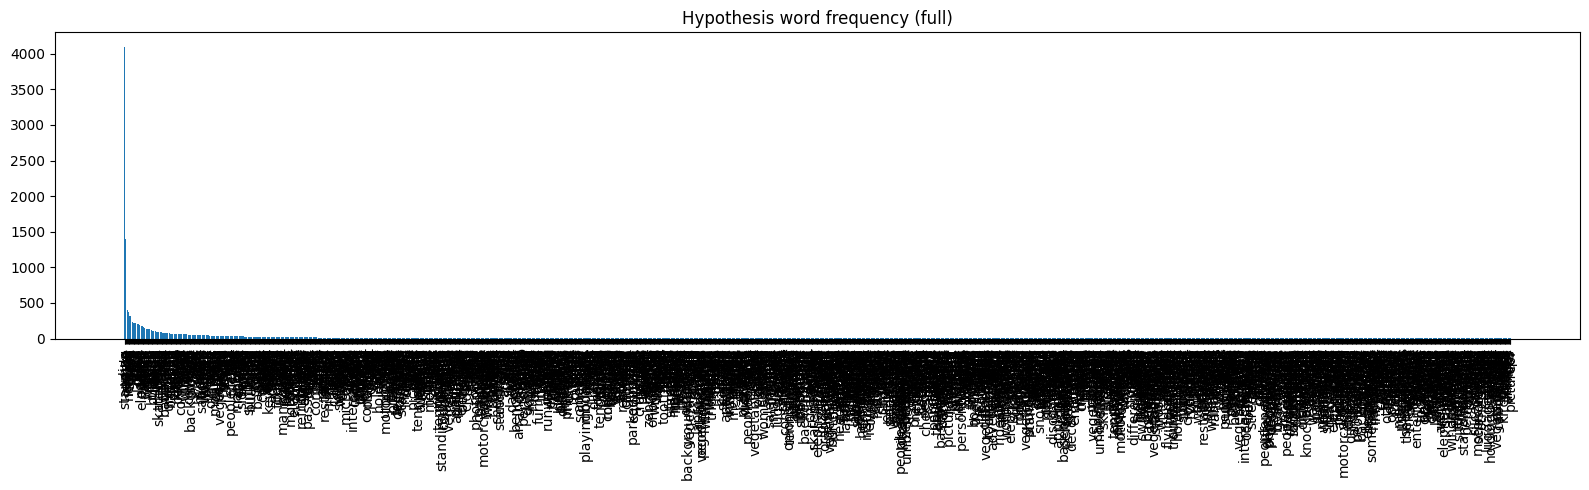

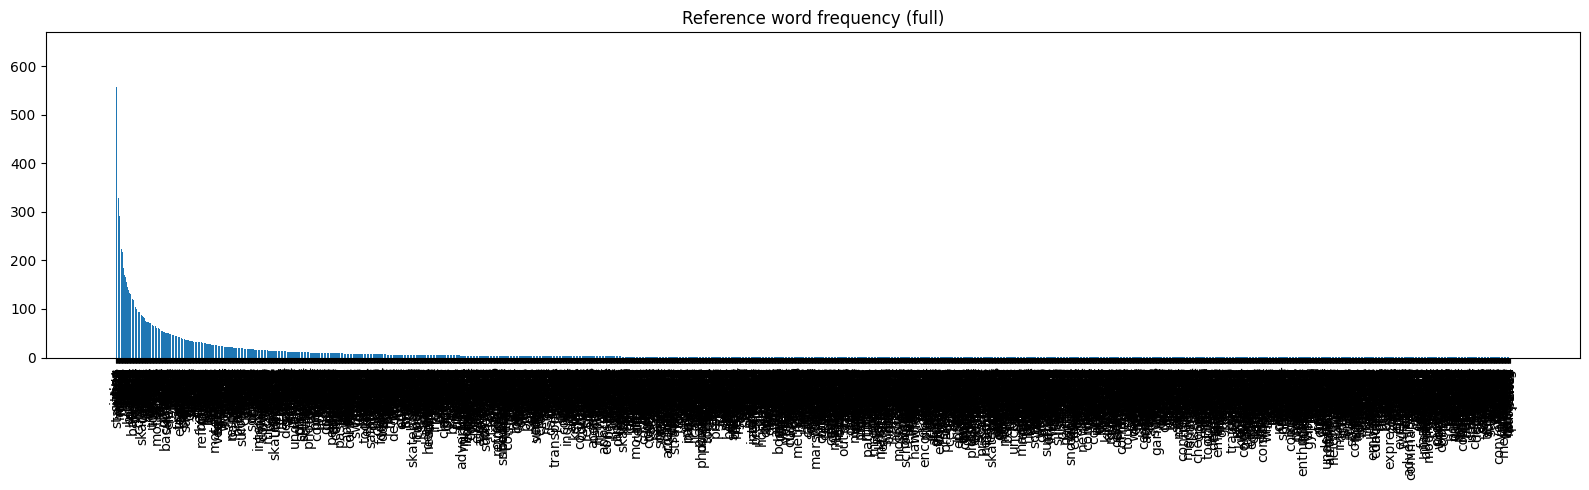

In [4]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
import string

# prepare stop‑words set once
stop_words = set(stopwords.words('english'))

def tokenize_and_clean(text):
    toks = word_tokenize(text.lower())
    # keep only alphabetic tokens and drop stopwords
    return [t for t in toks if t.isalpha() and t not in stop_words]

# add token lists to the dataframe
df['hyp_tokens'] = df['hypothesis'].apply(tokenize_and_clean)
df['ref_tokens'] = df['reference'].apply(tokenize_and_clean)

# flatten lists and count frequencies
hyp_counter = Counter(w for toks in df['hyp_tokens'] for w in toks)
ref_counter = Counter(w for toks in df['ref_tokens'] for w in toks)

# convert to dataframes sorted by frequency
hyp_df = pd.DataFrame(hyp_counter.most_common(), columns=['word', 'count'])
ref_df = pd.DataFrame(ref_counter.most_common(), columns=['word', 'count'])

# --- plot full distributions -----------------------------------------------
plt.figure(figsize=(16,5))
plt.bar(hyp_df['word'], hyp_df['count'])
plt.title('Hypothesis word frequency (full)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

plt.figure(figsize=(16,5))
plt.bar(ref_df['word'], ref_df['count'])
plt.title('Reference word frequency (full)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


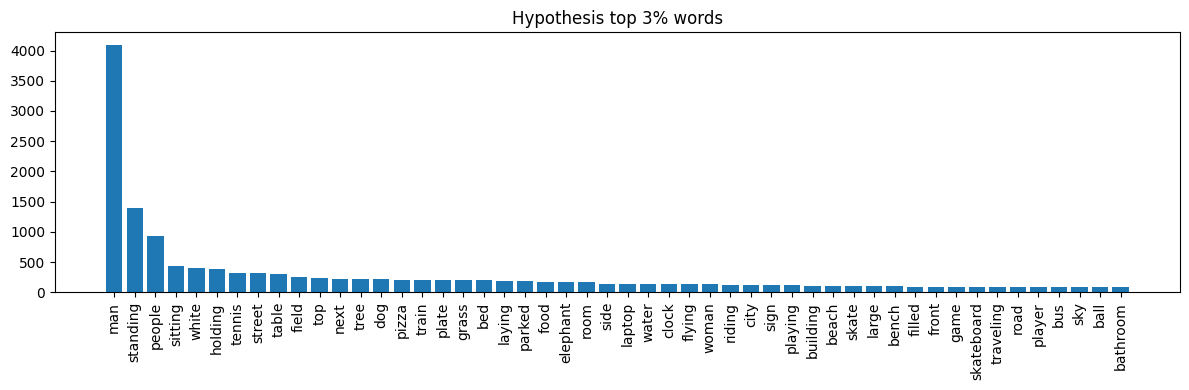

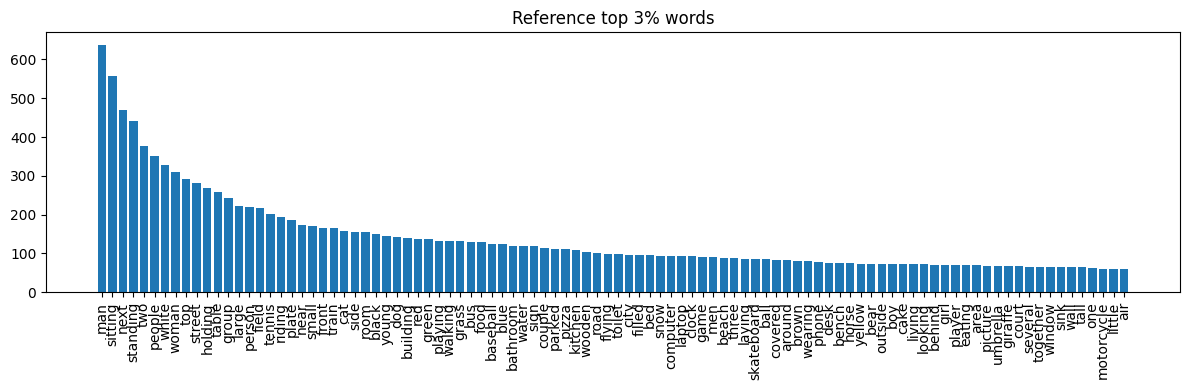

In [5]:
percent = 3
n_hyp = int(len(hyp_df) * 0.01*percent)
n_ref = int(len(ref_df) * 0.01*percent)

hyp_top = hyp_df.iloc[:n_hyp]
ref_top = ref_df.iloc[:n_ref]

plt.figure(figsize=(12,4))
plt.bar(hyp_top['word'], hyp_top['count'])
plt.title(f'Hypothesis top {percent}% words')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
plt.bar(ref_top['word'], ref_top['count'])
plt.title(f'Reference top {percent}% words')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

28987
24247


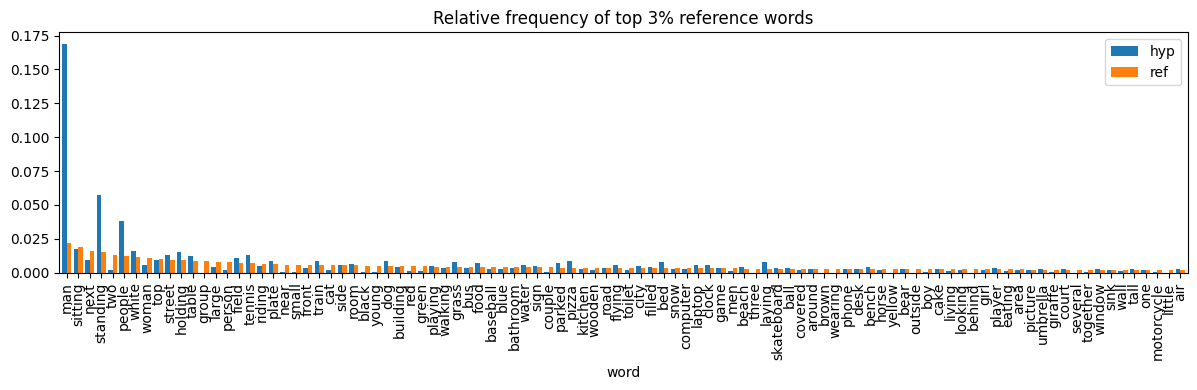

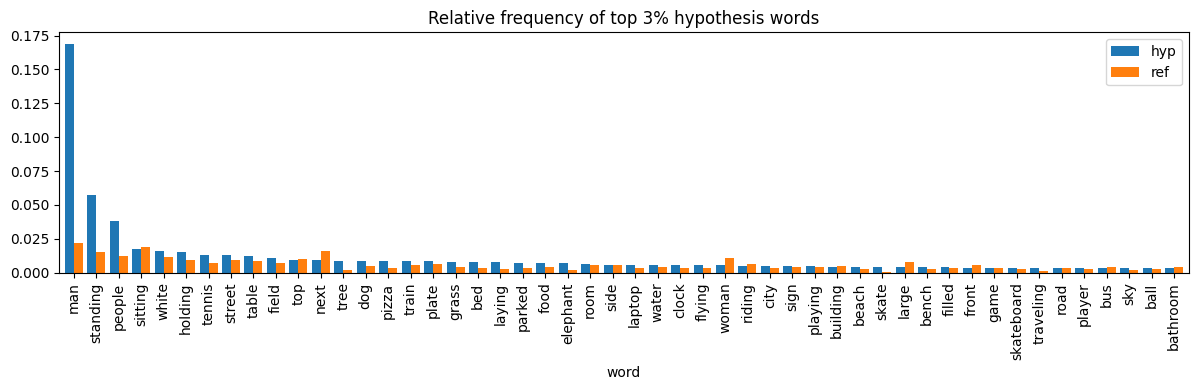

In [6]:
# total corpus sizes
total_hyp_tokens = sum(hyp_counter.values())
total_ref_tokens = sum(ref_counter.values())

# select top n% words
ref_top_words = ref_df.iloc[:n_ref]['word']
hyp_top_words = hyp_df.iloc[:n_hyp]['word']
print(total_ref_tokens)
print(total_hyp_tokens)

# helper: build dataframe with relative frequencies
def build_rel_freq_df(words, hyp_ctr, ref_ctr, total_hyp, total_ref):
    data = {
        "word": words,
        "hyp": [hyp_ctr.get(w, 0) / total_hyp for w in words],
        "ref": [ref_ctr.get(w, 0) / total_ref for w in words],
    }
    return pd.DataFrame(data).set_index("word")

# --- Top % reference words ---
df_refwords = build_rel_freq_df(
    ref_top_words,
    hyp_counter,
    ref_counter,
    total_hyp_tokens,
    total_ref_tokens,
)

df_refwords.plot(kind="bar", figsize=(12, 4), width=0.8)
plt.title(f"Relative frequency of top {percent}% reference words")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# --- Top % hypothesis words ---
df_hypwords = build_rel_freq_df(
    hyp_top_words,
    hyp_counter,
    ref_counter,
    total_hyp_tokens,
    total_ref_tokens,
)

df_hypwords.plot(kind="bar", figsize=(12, 4), width=0.8)
plt.title(f"Relative frequency of top {percent}% hypothesis words")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()